In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, nltk, os, glob, pickle
from utils import plot_style, norm01; plot_style('notebook');
import torch

* Generate one-hot stimulus vector of stim_dim=10 per timepoint across total_time = 100
* Variables to be defined up-top: n_events = 10; event_avg_len = total_time/n_events
* Per event, stimuli should be autoregressive, i.e., directedly autocorrelated; for example
    * 10100, 10000, 00000 as event stims, where
        * event_len = event_avg_len + noise = 3 in this example
        * autoreg_feat_size[event_i] = rand number <=int(stim_dim/2) = 3 in this example because
        * autoreg_features[event_i] = rand #autoreg_feat_size indices = [0,1,2] in this example because those dimensions seem to change progressively
        * autoreg_direction[event_i] = rand(0,1) = 0 in this example because 1s become 0s
    * Thoughts? Better ways to operationalize autoregression?
* Visualize time-time stim correlation heatmap in my plotting code style

In [4]:
# Parameters
rng = np.random.default_rng(42)
stim_dim, total_time, n_events = 10, 100, 10
event_avg_len = total_time / n_events

# generate event lengths via normal dist
event_lengths = rng.normal(event_avg_len, event_avg_len * 0.2, n_events).astype(int)
event_lengths = np.clip(event_lengths, 5, None)  # minimum event length of 5
event_lengths[-1] = total_time - event_lengths[:-1].sum()  # ensure final event's length sums to total_time
print(f"event_lengths: {event_lengths}  (sum={event_lengths.sum()})")

noise_std = 0.2   # std of Gaussian noise added at each AR step


event_lengths: [10  7 11 11  6  7 10  9  9 20]  (sum=100)


In [5]:
# Per-event autoregressive metadata
autoreg_feat_sizes = []  # number of autoregressive features per event
autoreg_features   = []  # which feature indices are autoregressive per event
autoreg_directions = []  # 0=decay (1→0), 1=build (0→1) per event

# Generate stimulus matrix with autoregressive event structure
stim = np.zeros((total_time, stim_dim))
event_templates = []   # (n_events, stim_dim) — ground-truth event fingerprints
event_start_t   = 0   # global timepoint where current event starts

for event_idx in range(n_events):
    event_len = event_lengths[event_idx]

    # Sample per-event autoregressive metadata
    n_autoreg = rng.integers(stim_dim // 4, stim_dim // 2 + 1)
    autoreg_feat_sizes.append(n_autoreg)
    ev_autoreg_features = rng.choice(stim_dim, n_autoreg, replace=False)
    autoreg_features.append(ev_autoreg_features)
    ev_stable_features  = np.setdiff1d(np.arange(stim_dim), ev_autoreg_features)

    direction = int(rng.integers(0, 2))
    autoreg_directions.append(direction)
    target        = 0.0 if direction == 0 else 1.0  # decay→0, build→1
    pull_strength = 1.0 / event_len  # norm by event_len

    # Sample event template (continuous uniform [0,1]) — unique fingerprint for this event
    event_template = rng.random(stim_dim)
    event_templates.append(event_template.copy())

    # Initialize autoreg feature values at event template
    x_prev = event_template[ev_autoreg_features].copy()

    for event_t in range(event_len):
        t = event_start_t + event_t

        # OU-style AR(1): pull toward target proportional to remaining distance, plus noise
        dist_to_target = target - x_prev
        x_t            = x_prev + pull_strength * dist_to_target + rng.normal(0, noise_std, len(ev_autoreg_features))
        x_t            = np.clip(x_t, 0, 1)  # keep in valid range
        stim[t, ev_autoreg_features] = x_t
        x_prev                       = x_t

        # Stable features: jitter around template value to avoid perfect within-event lock
        stim[t, ev_stable_features] = np.clip(event_template[ev_stable_features] + rng.normal(0, noise_std, len(ev_stable_features)), 0, 1)

    event_start_t += event_len

autoreg_directions = np.array(autoreg_directions)
event_templates    = np.array(event_templates)  # (n_events, stim_dim)

print(f"stim shape : {stim.shape}")
print(f"stim range : [{stim.min():.2f}, {stim.max():.2f}]")
print(f"Total timepoints filled: {event_start_t}")


stim shape : (100, 10)
stim range : [0.00, 1.00]
Total timepoints filled: 100


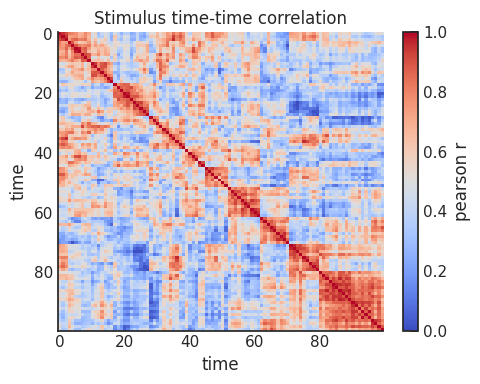

In [6]:

fig, ax = plt.subplots(figsize=(5,4))
ax.set(title='Stimulus time-time correlation', xlabel='time', ylabel='time')
im = ax.imshow(norm01(np.corrcoef(stim)), aspect='auto', cmap='coolwarm', vmin=0, vmax=1,
               origin='upper', interpolation='nearest')
plt.colorbar(im, ax=ax, label='pearson r')
plt.tight_layout()
plt.show()
